## Model Training + Hyper parameters Tuning
Workflow: EDA → Feature Engineering → Data Cleaning → Model Training → Hyperparameter Tuning

#### Dataset: Algerian Forest Fires
- Contains 244 instances combining data from two regions of Algeria: Bejaia region (north-east) and Sidi Bel Abbes region (north-west).
- Time period: June 2012 to September 2012
- 11 attributes + 1 output attribute (Classes)
- Instances are classified into fire / not fire classes (can be used for classification too)
- For the regression problem, the target feature is FWI (Fire Weather Index); all other columns become independent features

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Algerian_forest_fires.csv', header=1) #header tells which row should be used for column name
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          246 non-null    str  
 1   month        245 non-null    str  
 2   year         245 non-null    str  
 3   Temperature  245 non-null    str  
 4    RH          245 non-null    str  
 5    Ws          245 non-null    str  
 6   Rain         245 non-null    str  
 7   FFMC         245 non-null    str  
 8   DMC          245 non-null    str  
 9   DC           245 non-null    str  
 10  ISI          245 non-null    str  
 11  BUI          245 non-null    str  
 12  FWI          245 non-null    str  
 13  Classes      244 non-null    str  
dtypes: str(14)
memory usage: 38.2 KB


All columns show string so we will have to fix it.

## DATA CLEANING

In [3]:
df.isnull().sum()

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
dtype: int64

View the rows which has missing values then drop them

In [13]:
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region


In [12]:
df=df.dropna().reset_index(drop=True)
df=df.drop(122).reset_index(drop=True)
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

Column names might containt trailing spaces. Fix it

In [7]:
df.columns = df.columns.str.strip()

- Rows 0–121 belong to the Bejaia region; rows 122 onward belong to Sidi Bel Abbes.
- A new Region column is created to label these: 0 = Bejaia, 1 = Sidi Bel Abbes

In [14]:
df.loc[:122, 'Region'] = 0
df.loc[122:, 'Region'] = 1
df=df
print(df[120:])

    day month  year Temperature  RH  Ws Rain  FFMC  DMC    DC  ISI   BUI  FWI  \
120  29    09  2012          26  80  16  1.8  47.4  2.9   7.7  0.3     3  0.1   
121  30    09  2012          25  78  14  1.4    45  1.9   7.5  0.2   2.4  0.1   
122  01    06  2012          32  71  12  0.7  57.1  2.5   8.2  0.6   2.8  0.2   
123  02    06  2012          30  73  13    4  55.7  2.7   7.8  0.6   2.9  0.2   
124  03    06  2012          29  80  14    2  48.7  2.2   7.6  0.3   2.6  0.1   
..   ..   ...   ...         ...  ..  ..  ...   ...  ...   ...  ...   ...  ...   
238  26    09  2012          30  65  14    0  85.4   16  44.5  4.5  16.9  6.5   
239  27    09  2012          28  87  15  4.4  41.1  6.5     8  0.1   6.2    0   
240  28    09  2012          27  87  29  0.5  45.9  3.5   7.9  0.4   3.4  0.2   
241  29    09  2012          24  54  18  0.1  79.7  4.3  15.2  1.7   5.1  0.7   
242  30    09  2012          24  64  15  0.2  67.3  3.8  16.5  1.2   4.8  0.5   

          Classes  Region  

Convert region's datatype from float to int

In [16]:
df['Region'] = df['Region'].astype(int)
df.dtypes

day              str
month            str
year             str
Temperature      str
RH               str
Ws               str
Rain             str
FFMC             str
DMC              str
DC               str
ISI              str
BUI              str
FWI              str
Classes          str
Region         int64
dtype: object

#### Convert Datatypes
Convert the ones with whole numbers into int and other into float except for classes column since its needed to be like that

In [17]:
df[['month', 'day', 'year', 'Temperature', 'RH', 'Ws']] = \
    df[['month', 'day', 'year', 'Temperature', 'RH', 'Ws']].astype(int)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          243 non-null    int64
 1   month        243 non-null    int64
 2   year         243 non-null    int64
 3   Temperature  243 non-null    int64
 4   RH           243 non-null    int64
 5   Ws           243 non-null    int64
 6   Rain         243 non-null    str  
 7   FFMC         243 non-null    str  
 8   DMC          243 non-null    str  
 9   DC           243 non-null    str  
 10  ISI          243 non-null    str  
 11  BUI          243 non-null    str  
 12  FWI          243 non-null    str  
 13  Classes      243 non-null    str  
 14  Region       243 non-null    int64
dtypes: int64(7), str(8)
memory usage: 36.1 KB


In [18]:
df[['Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI']] = \
    df[['Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI']].astype(float)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    str    
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), str(1)
memory usage: 30.7 KB


In [19]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


In [49]:
df_copy = df

Since the goal is to predict FWI (not date-based patterns), the day, month, and year columns aren't needed

In [50]:
df_copy = df_copy.drop(['day','month','year'], axis=1)
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


### Data Encoding
Since Classes is a categorical feature (fire / not fire), it needs to be encoded into numeric labels (0/1) before it can be used in any model.

In [ ]:
df_copy['Classes'] = np.where(df_copy['Classes'] == 'not fire', 0, 1)   #dont run

In [51]:
df_copy['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

This issue is because raw data contained inconsistent trailing spaces. so all others like ' not fire' or 'not fire  ' were ignored. We have to fix it by using .contains

In [52]:
df_copy['Classes'] = np.where(df_copy['Classes'].str.contains('not fire'), 0, 1)
df_copy['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

## Density Plots
Quickly inspect the distribution (skewness, normality) of every numerical feature at once.

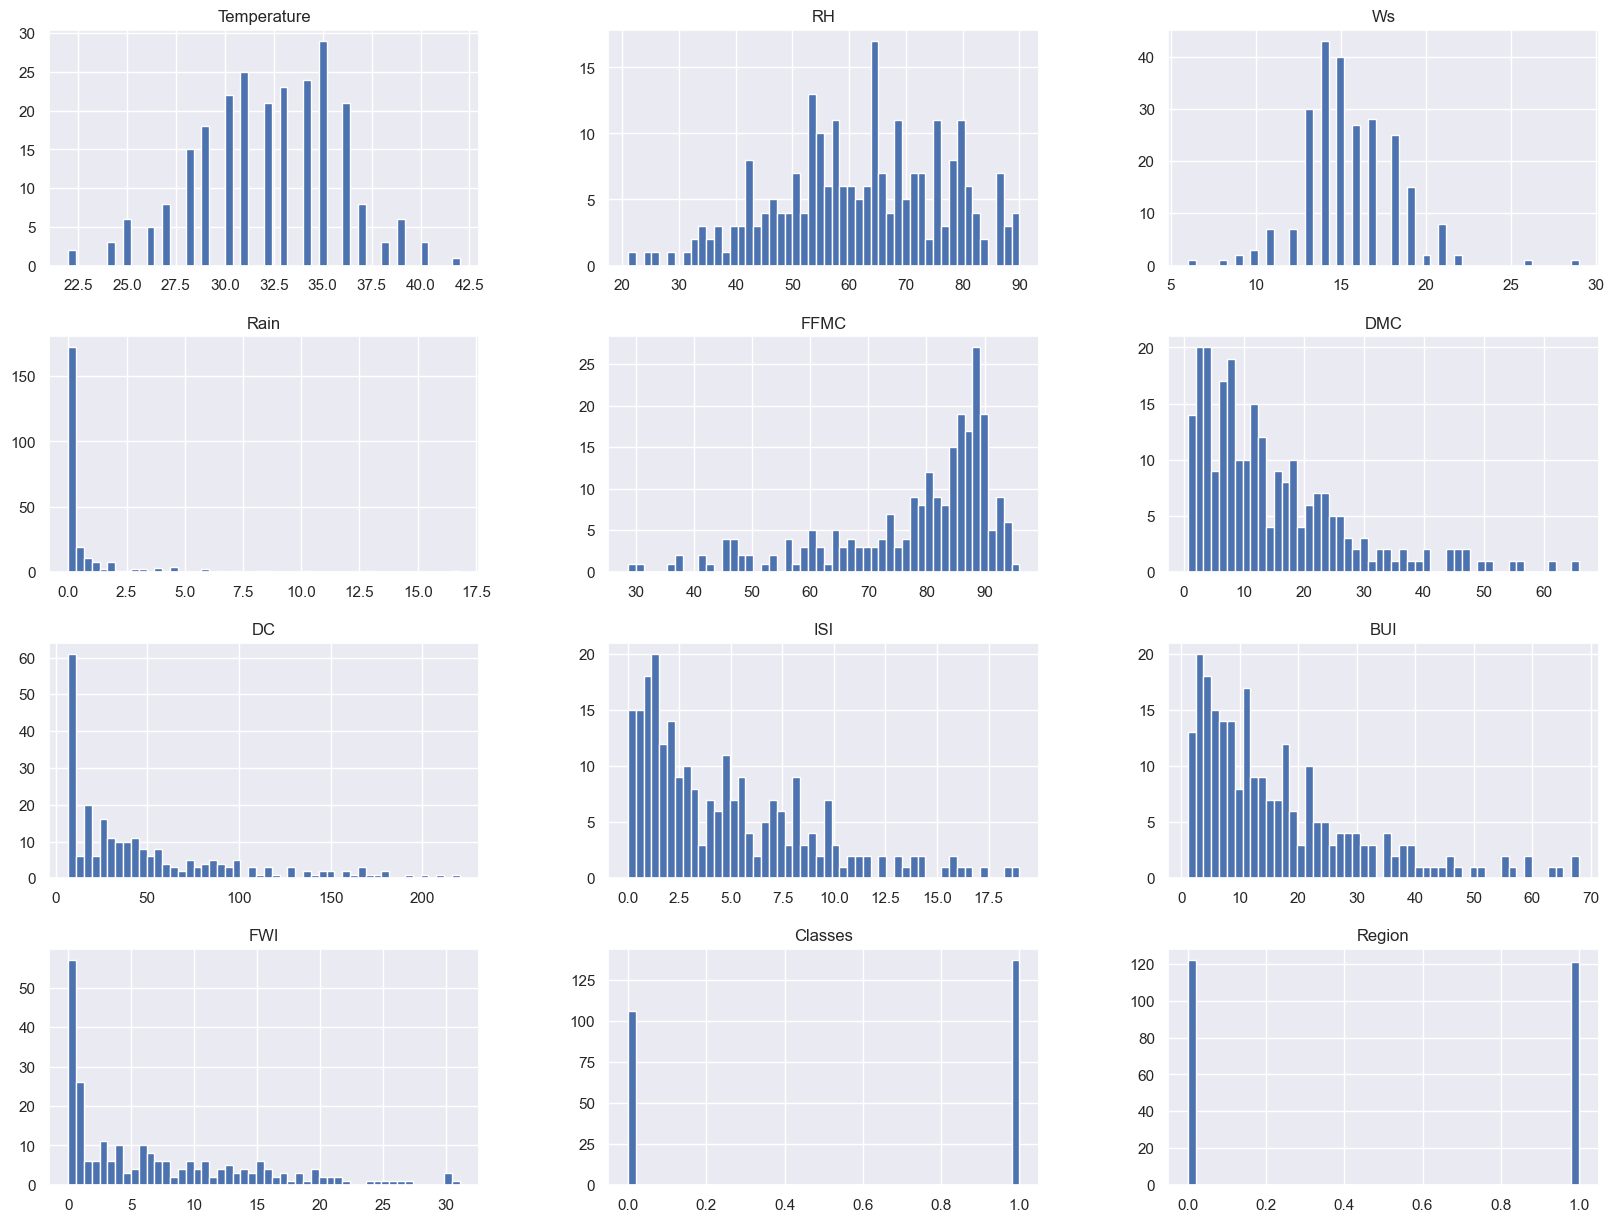

In [53]:
sns.set_theme(style="darkgrid") 
df_copy.hist(bins=50, figsize=(20, 15))
plt.show()

most features are left/right skewed and only few are normally distributed.

## Pie Chart - Fire vs not Fire

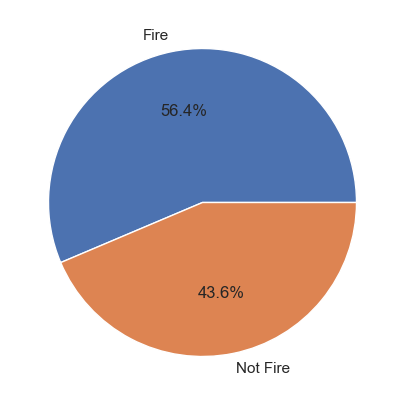

In [54]:
percentage = df_copy['Classes'].value_counts(normalize=True)
labels = ['Fire', 'Not Fire']
plt.figure(figsize=(10,5))
plt.pie(percentage,labels=labels,autopct='%1.1f%%')
plt.show()

## Correlation and Multicollinearity Check
Identify relationships between independent features (and with the dependent feature FWI) to guide feature selection later.

In [55]:
df_copy.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


- Diagonal = 1 (feature perfectly correlated with itself)
- RH vs Temperature: correlation ≈ −0.65 → inversely related (as humidity rises, temperature drops)
- Rain vs Temperature: negative correlation (heavy rain → lower temperature)
- FFMC vs Temperature: ≈ +0.67 → positively related (as FFMC increases, temperature tends to increase)

<Axes: >

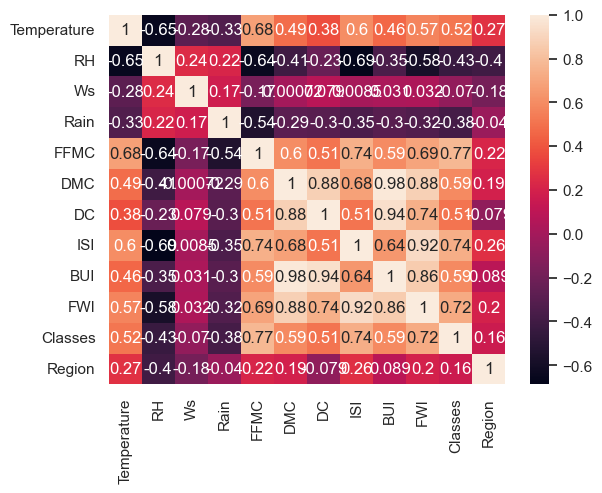

In [57]:
sns.heatmap(df_copy.corr(),annot=True)

## Box Plot - Outlier check on FWI

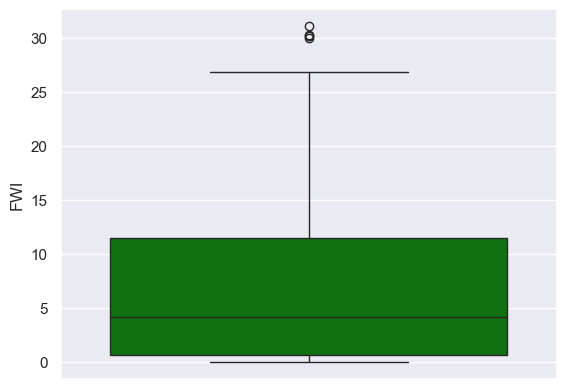

In [58]:
fig, ax = plt.subplots()
sns.boxplot(df['FWI'],color='green')
plt.show()

## Monthly Fire Analysis - Regionwise (countplot)

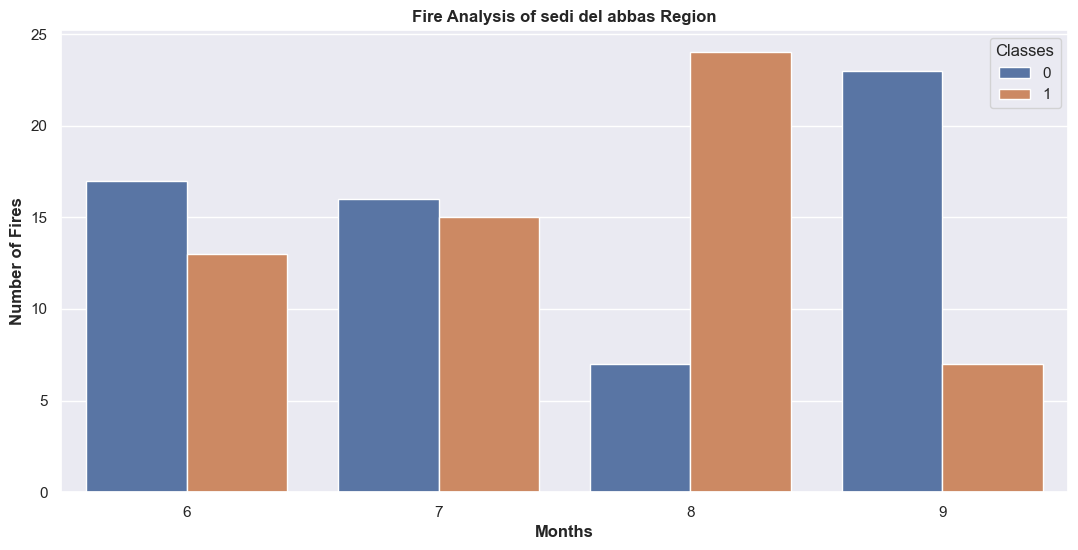

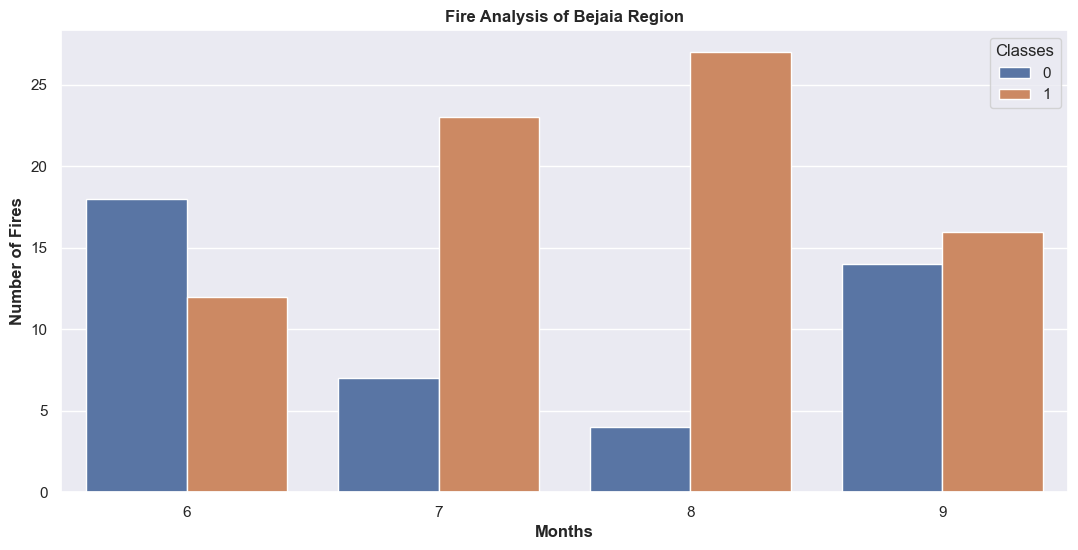

In [64]:
df_sediBelAbbas = df.loc[df['Region']==0]
df_sediBelAbbas['Classes'] = np.where(df_sediBelAbbas['Classes'].str.contains('not fire'), 0, 1)
plt.subplots(figsize=(13,6))
sns.countplot(x='month', hue='Classes', data=df_sediBelAbbas)
plt.ylabel('Number of Fires', weight='bold')
plt.xlabel('Months', weight='bold')
plt.title('Fire Analysis of sedi del abbas Region', weight='bold')
plt.show()

df_Bejaia = df.loc[df['Region']==1]
df_Bejaia['Classes'] = np.where(df_Bejaia['Classes'].str.contains('not fire'), 0, 1)
plt.subplots(figsize=(13,6))
sns.countplot(x='month', hue='Classes', data=df_Bejaia)
plt.ylabel('Number of Fires', weight='bold')
plt.xlabel('Months', weight='bold')
plt.title('Fire Analysis of Bejaia Region', weight='bold')
plt.show()

In [65]:
df = df_copy

## Feature Selecion

FWI is the dependent/target feature; everything else (including Classes) is treated as an independent feature for this regression task.

In [66]:
X=df.drop('FWI', axis=1, inplace=False)
y=df['FWI']
print(X.shape, y.shape)

(243, 11) (243,)


In [67]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


#### Feature Selection based on MultiCollinearity
Multicollinearity means independent features are highly correlated with each other. Highly correlated features add redundancy without adding new information, so one of each correlated pair can be dropped.

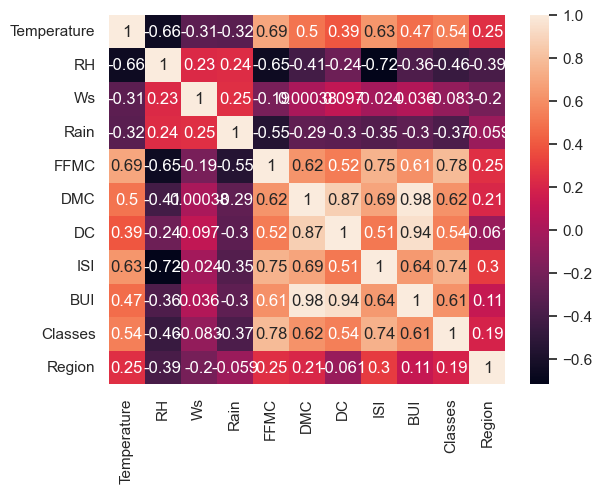

In [68]:
sns.heatmap(X_train.corr(), annot=True)
plt.show()

A set is used to store only unique column names. The function iterates through the correlation matrix and, wherever the correlation between two features exceeds a given threshold, adds that column name to the set.

In [69]:
colCorr = set()
corrMatrix = X_train.corr()
for i in range(len(corrMatrix.columns)):
    for j in range(i):
        if abs(corrMatrix.iloc[i,j]) > 0.85:
            colCorr.add(corrMatrix.columns[i])
print(colCorr)

{'DC', 'BUI'}


In [70]:
X_train.drop(colCorr, axis=1, inplace=True)
X_test.drop(colCorr, axis=1, inplace=True)
print(X_train.shape, X_test.shape)

(182, 9) (61, 9)


Now Do Feature Scaling and visualize its effect

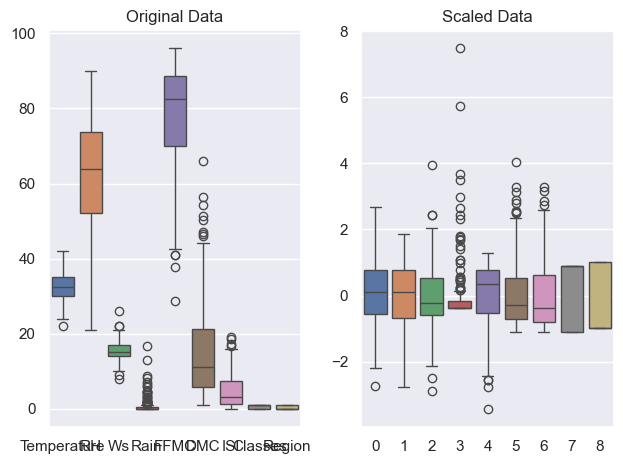

In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

fig, axes = plt.subplots(1,2)
sns.boxplot(data=X_train, ax=axes[0])
axes[0].set_title("Original Data")
sns.boxplot(data=X_train_scaled, ax=axes[1])
axes[1].set_title("Scaled Data")
plt.tight_layout()
plt.show()

See how all boxes are centerred it means data is scaled. Labelling looks weird which is not a concern but can be fixed.

C:\Users\ssa56\AppData\Local\Temp\ipykernel_19452\3501540911.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
C:\Users\ssa56\AppData\Local\Temp\ipykernel_19452\3501540911.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)


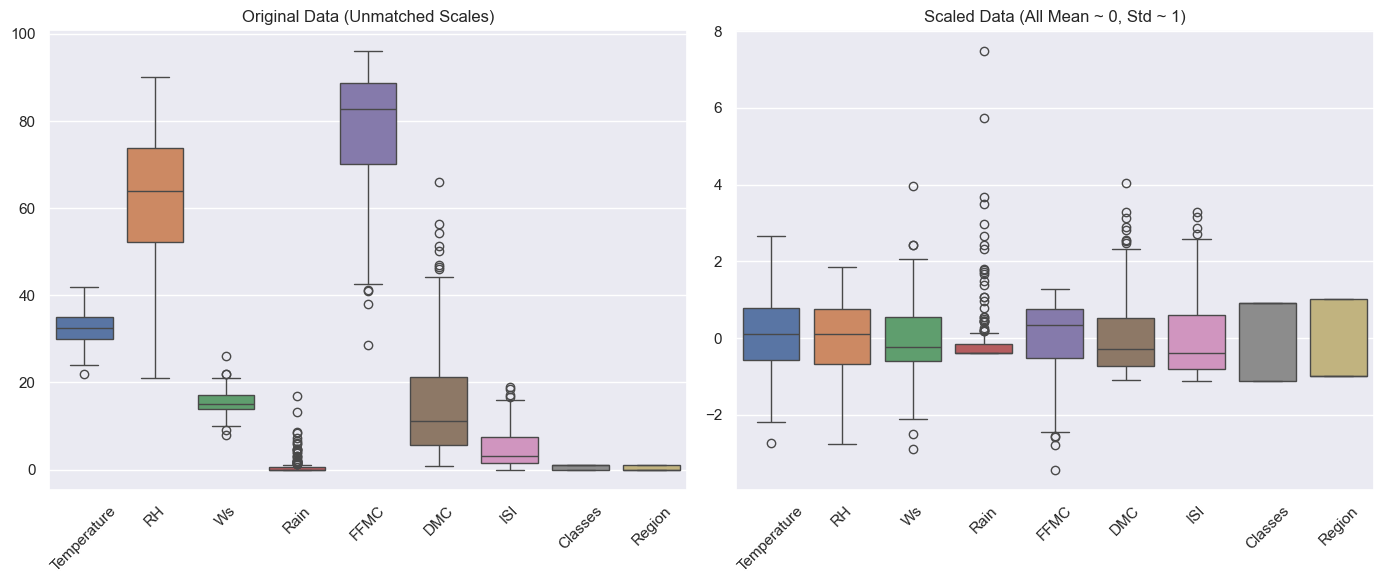

In [74]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original Data
sns.boxplot(data=X_train, ax=axes[0])
axes[0].set_title("Original Data (Unmatched Scales)")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# Scaled Data with proper names
sns.boxplot(data=X_train_scaled_df, ax=axes[1])
axes[1].set_title("Scaled Data (All Mean ~ 0, Std ~ 1)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# MODEL TRAINING

### Linear Regression - standard model

In [75]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)

y_pred = linreg.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print(mae)
print(score)

0.5468236465249978
0.9847657384266951


R2_score is very high which can mean overfitting so lets visualize this (linear graph means we cool).

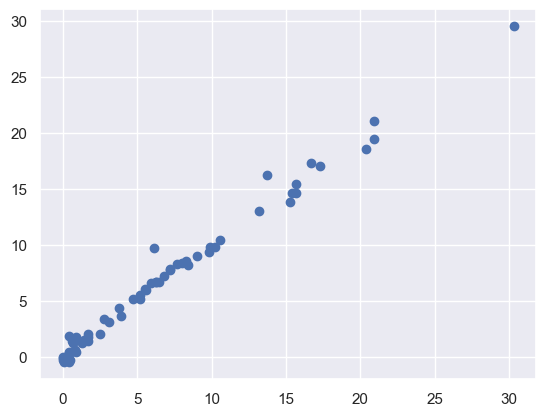

In [76]:
plt.scatter(y_test,y_pred)

## Lasso Regression 
Same workflow as LR but applies L1 regularization

In [77]:
from sklearn.linear_model import Lasso

lassoReg = Lasso()
lassoReg.fit(X_train_scaled, y_train)

y_pred = lassoReg.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print(mae)
print(score)

1.1331759949144087
0.9492020263112388


Even though r2_score is lower but it dont mean worse performance it means generalized better.

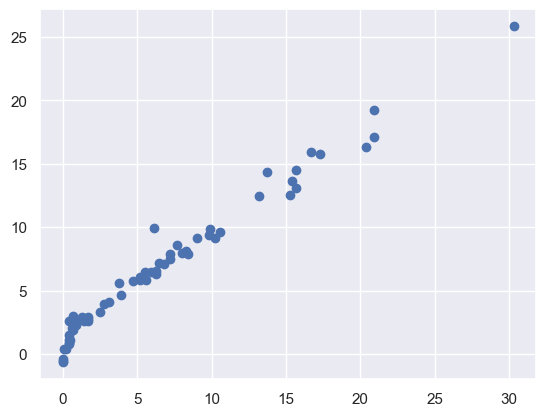

In [78]:
plt.scatter(y_test,y_pred)

In [79]:
from sklearn.linear_model import Ridge

ridgeReg = Ridge()
ridgeReg.fit(X_train_scaled, y_train)

y_pred = ridgeReg.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print(mae)
print(score)

0.5642305340105715
0.9842993364555512


We see strong R2 score yet applying regularization so its very nice

In [80]:
from sklearn.linear_model import ElasticNet

elasticNetReg = ElasticNet()
elasticNetReg.fit(X_train_scaled, y_train)

y_pred = elasticNetReg.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print(mae)
print(score)

1.8822353634895999
0.8753460589519703


Key parameters to tune:
- alpha — overall regularization strength
- l1_ratio — controls the balance between L1 (feature selection) and L2 (overfitting control) — how much importance to give to each

### Cross Validation
Rather than manually guessing alpha values, sklearn provides CV-specific versions of these models (e.g., LassoCV) that automatically search for the best alpha via cross-validation.
We will test LassoCV, RidgeCV and elastic net CV

In [83]:
from sklearn.linear_model import LassoCV
lasso_cv = LassoCV(cv=5)
lasso_cv.fit(X_train_scaled, y_train)
y_pred = lasso_cv.predict(X_test_scaled)

#check selected alpha
lasso_cv.alpha_

np.float64(0.06582808719529475)

In [84]:
#check all alphas tried
lasso_cv.alphas_

array([7.05853002, 6.58280872, 6.13914944, 5.72539132, 5.33951911,
       4.97965339, 4.64404142, 4.33104857, 4.03915039, 3.76692517,
       3.51304702, 3.27627941, 3.05546914, 2.84954075, 2.65749124,
       2.47838523, 2.31135036, 2.15557308, 2.01029467, 1.87480753,
       1.74845178, 1.63061198, 1.52071419, 1.41822315, 1.32263965,
       1.23349817, 1.15036452, 1.0728338 , 1.00052839, 0.93309613,
       0.87020857, 0.81155943, 0.75686304, 0.705853  , 0.65828087,
       0.61391494, 0.57253913, 0.53395191, 0.49796534, 0.46440414,
       0.43310486, 0.40391504, 0.37669252, 0.3513047 , 0.32762794,
       0.30554691, 0.28495408, 0.26574912, 0.24783852, 0.23113504,
       0.21555731, 0.20102947, 0.18748075, 0.17484518, 0.1630612 ,
       0.15207142, 0.14182231, 0.13226397, 0.12334982, 0.11503645,
       0.10728338, 0.10005284, 0.09330961, 0.08702086, 0.08115594,
       0.0756863 , 0.0705853 , 0.06582809, 0.06139149, 0.05725391,
       0.05339519, 0.04979653, 0.04644041, 0.04331049, 0.04039

0.6358894638564663 0.9814406737205228


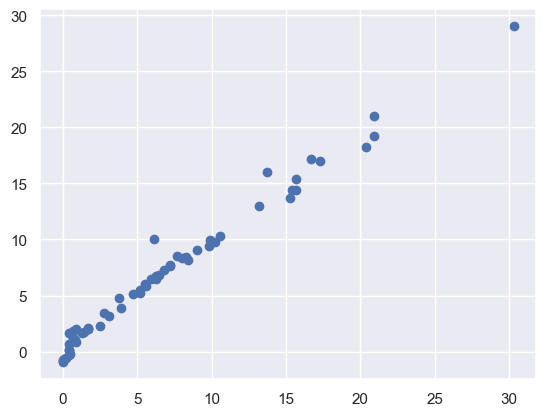

In [86]:
plt.scatter(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print(mae, score)

Good Linear Relationship - Low MAE score and Good R2 score

1.0


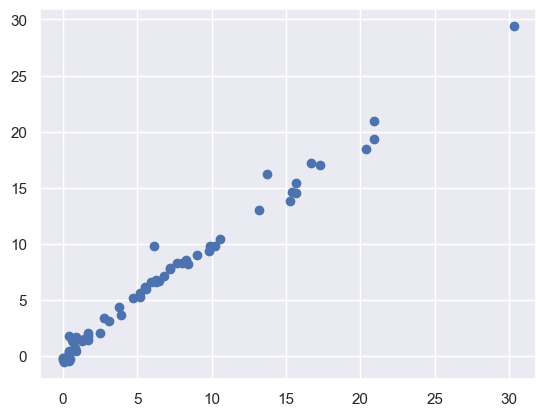

In [88]:
from sklearn.linear_model import RidgeCV
ridge_cv = RidgeCV(cv=5)
ridge_cv.fit(X_train_scaled, y_train)
y_pred = ridge_cv.predict(X_test_scaled)

#check selected alpha
print(ridge_cv.alpha_)
plt.scatter(y_test, y_pred)

0.06582808719529475


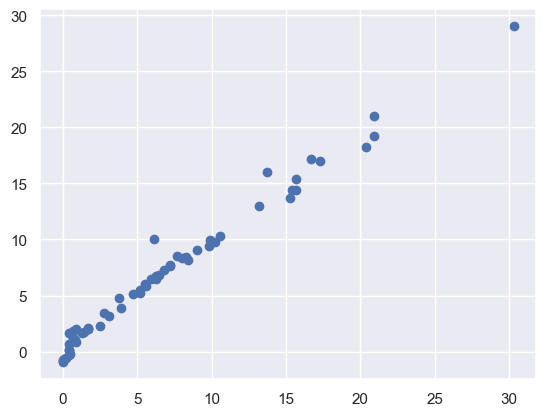

In [90]:
from sklearn.linear_model import LassoCV
lasso_cv = LassoCV(cv=5)
lasso_cv.fit(X_train_scaled, y_train)
y_pred = lasso_cv.predict(X_test_scaled)

#check selected alpha
print(lasso_cv.alpha_)
plt.scatter(y_test, y_pred)